# Particle neighbourhood analysis notebook

This notebook does the following:

0. reads `fcc/particle_data.npz`, `hcp/particle_data.npz`, `liquid/particle_data.npz`
1. sorts the scalar neighbour distances and reorders the neighbour vectors accordingly
2. plots histograms of `w4` and `w6`
3. plots `q4` vs `q6`
4. evaluates PTM/CNA as labeling models
5. trains a **simple shallow autoencoder** for:
   - `liquid` vs `fcc`
   - `liquid` vs `fcc` vs `hcp`

for each of:
- `dist`
- `vec_dist`
- `ql`

Additionally, for each autoencoder result, the notebook:
- plots the latent bottleneck
- plots the corresponding `q4` vs `q6` scatter for the same subset
- trains a classifier on the bottleneck and reports the results

All scatter plots use:
- very small point size
- `alpha = 0.2`


In [49]:
# Imports
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset


In [50]:
# Configuration
DATA_DIR = Path(".")
PHASES = ["fcc", "hcp", "liquid"]

LABEL_MAP = {"fcc": 0, "hcp": 1, "liquid": 2}
LABEL_NAMES = {0: "fcc", 1: "hcp", 2: "liquid"}
LABEL_COLORS = {0: "tab:blue", 1: "tab:orange", 2: "tab:green"}

SCATTER_S = 1
SCATTER_ALPHA = 0.2

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPOCHS = 50
BATCH_SIZE = 256
LR = 1e-3
LATENT_DIM = 2

print("Using device:", DEVICE)


Using device: cpu


## 0) Read data

In [51]:
def load_particle_data(npz_path):
    arr = np.load(npz_path, allow_pickle=True)
    out = {}

    out["dist"] = arr["dist"].astype(np.float32)
    out["w4w6"] = arr["w4w6"].astype(np.float32)
    if "w4w6_no_average" in arr:
        out["w4w6_no_average"] = arr["w4w6_no_average"].astype(np.float32)
    if "picked_ids" in arr:
        out["picked_ids"] = arr["picked_ids"].astype(np.int32)
    if "frame_indices" in arr:
        out["frame_indices"] = arr["frame_indices"].astype(np.int32)
    out["ql"] = arr["ql"].astype(np.float32)
    if "ql_no_average" in arr:
        out["ql_no_average"] = arr["ql_no_average"].astype(np.float32)
    if "ptm" in arr:
        out["ptm"] = arr["ptm"].astype(np.float32)
    if "ptm_rmsd_by_type" in arr:
        out["ptm_rmsd_by_type"] = arr["ptm_rmsd_by_type"].astype(np.float32)
    if "ptm_rmsd_type_names" in arr:
        out["ptm_rmsd_type_names"] = arr["ptm_rmsd_type_names"]
    if "cna" in arr:
        out["cna"] = arr["cna"].astype(np.int8)
    if "cna_columns" in arr:
        out["cna_columns"] = arr["cna_columns"]
    if "ptm_denoised" in arr:
        out["ptm_denoised"] = arr["ptm_denoised"].astype(np.float32)
    if "ptm_denoised_rmsd_by_type" in arr:
        out["ptm_denoised_rmsd_by_type"] = arr["ptm_denoised_rmsd_by_type"].astype(np.float32)
    if "ptm_denoised_rmsd_type_names" in arr:
        out["ptm_denoised_rmsd_type_names"] = arr["ptm_denoised_rmsd_type_names"]
    if "cna_denoised" in arr:
        out["cna_denoised"] = arr["cna_denoised"].astype(np.int8)
    if "cna_denoised_columns" in arr:
        out["cna_denoised_columns"] = arr["cna_denoised_columns"]
    if "denoise_structure" in arr:
        out["denoise_structure"] = str(arr["denoise_structure"])
    if "denoise_steps" in arr:
        out["denoise_steps"] = int(arr["denoise_steps"])

    vec = arr["vec_dist"]
    if vec.ndim == 3 and vec.shape[2] == 3:
        out["vec_dist"] = vec.astype(np.float32)
    elif vec.ndim == 2 and vec.shape[1] % 3 == 0:
        n_neigh = vec.shape[1] // 3
        out["vec_dist"] = vec.reshape(vec.shape[0], n_neigh, 3).astype(np.float32)
    else:
        raise ValueError(f"Unexpected vec_dist shape in {npz_path}: {vec.shape}")

    return out


In [52]:
data_by_label = {}

for phase in PHASES:
    f = DATA_DIR / phase / "particle_data.npz"
    if not f.exists():
        raise FileNotFoundError(f"Could not find {f.resolve()}")
    data_by_label[phase] = load_particle_data(f)
    extra = []
    if "w4w6_no_average" in data_by_label[phase]:
        extra.append(f"w4w6_no_average {data_by_label[phase]['w4w6_no_average'].shape}")
    if "ql_no_average" in data_by_label[phase]:
        extra.append(f"ql_no_average {data_by_label[phase]['ql_no_average'].shape}")
    if "ptm" in data_by_label[phase]:
        extra.append(f"ptm {data_by_label[phase]['ptm'].shape}")
    if "ptm_rmsd_by_type" in data_by_label[phase]:
        extra.append(f"ptm_rmsd_by_type {data_by_label[phase]['ptm_rmsd_by_type'].shape}")
    if "cna" in data_by_label[phase]:
        extra.append(f"cna {data_by_label[phase]['cna'].shape}")
    if "ptm_denoised" in data_by_label[phase]:
        extra.append(f"ptm_denoised {data_by_label[phase]['ptm_denoised'].shape}")
    if "ptm_denoised_rmsd_by_type" in data_by_label[phase]:
        extra.append(
            f"ptm_denoised_rmsd_by_type {data_by_label[phase]['ptm_denoised_rmsd_by_type'].shape}"
        )
    if "cna_denoised" in data_by_label[phase]:
        extra.append(f"cna_denoised {data_by_label[phase]['cna_denoised'].shape}")
    print(
        f"{phase:>6s}: "
        f"dist {data_by_label[phase]['dist'].shape}, "
        f"vec_dist {data_by_label[phase]['vec_dist'].shape}, "
        f"w4w6 {data_by_label[phase]['w4w6'].shape}, "
        f"ql {data_by_label[phase]['ql'].shape}"
        + (", " + ", ".join(extra) if extra else "")
    )


   fcc: dist (180300, 12), vec_dist (180300, 12, 3), w4w6 (180300, 2), ql (180300, 20), w4w6_no_average (180300, 2), ql_no_average (180300, 20), ptm (180300, 7), ptm_rmsd_by_type (180300, 4), cna (180300, 3)
   hcp: dist (180300, 12), vec_dist (180300, 12, 3), w4w6 (180300, 2), ql (180300, 20), w4w6_no_average (180300, 2), ql_no_average (180300, 20), ptm (180300, 7), ptm_rmsd_by_type (180300, 4), cna (180300, 3)
liquid: dist (90300, 12), vec_dist (90300, 12, 3), w4w6 (90300, 2), ql (90300, 20), w4w6_no_average (90300, 2), ql_no_average (90300, 20), ptm (90300, 7), ptm_rmsd_by_type (90300, 4), cna (90300, 3)


## 0b) Sort scalar distances and reorder `vec_dist` accordingly

In [53]:
for phase in PHASES:
    dist = data_by_label[phase]["dist"]      # (N, n_neigh)
    vec = data_by_label[phase]["vec_dist"]   # (N, n_neigh, 3)

    order = np.argsort(dist, axis=1)
    dist_sorted = np.take_along_axis(dist, order, axis=1)
    vec_sorted = np.take_along_axis(vec, order[:, :, None], axis=1)

    data_by_label[phase]["dist"] = dist_sorted
    data_by_label[phase]["vec_dist"] = vec_sorted

print("Sorted dist and reordered vec_dist consistently.")

for phase in PHASES:
    print(f"{phase} first sorted dist row:", data_by_label[phase]["dist"][0])


Sorted dist and reordered vec_dist consistently.
fcc first sorted dist row: [0.9660761 1.023752  1.0242254 1.0281578 1.0291507 1.0368468 1.0715846
 1.0765045 1.105943  1.1485935 1.1745137 1.340658 ]
hcp first sorted dist row: [0.9669518 0.9931411 1.015487  1.0384364 1.0402735 1.0845158 1.0868541
 1.093681  1.1012931 1.1286143 1.1287131 1.1345011]
liquid first sorted dist row: [0.95527    0.9621944  0.97467285 0.9988437  1.0134077  1.0190637
 1.0327059  1.0543592  1.0634786  1.1186303  1.2523485  1.3431684 ]


## 1) Row plot: histograms of $w_4$ and $w_6$

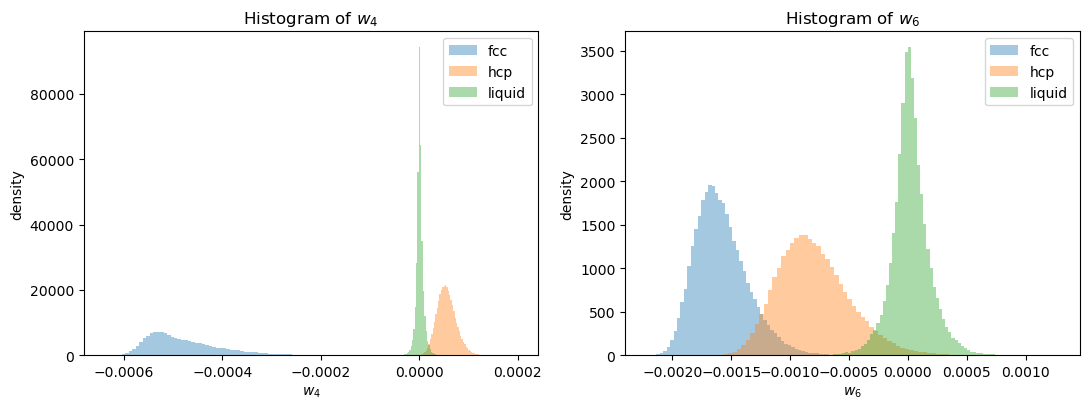

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

for phase in PHASES:
    lab = LABEL_MAP[phase]
    w4 = data_by_label[phase]["w4w6"][:, 0]
    w6 = data_by_label[phase]["w4w6"][:, 1]

    axes[0].hist(
        w4, bins=80, density=True, alpha=0.4,
        color=LABEL_COLORS[lab], label=phase
    )
    axes[1].hist(
        w6, bins=80, density=True, alpha=0.4,
        color=LABEL_COLORS[lab], label=phase
    )

axes[0].set_title("Histogram of $w_4$")
axes[0].set_xlabel("$w_4$")
axes[0].set_ylabel("density")
axes[0].legend()

axes[1].set_title("Histogram of $w_6$")
axes[1].set_xlabel("$w_6$")
axes[1].set_ylabel("density")
axes[1].legend()

plt.tight_layout()
plt.show()


## 1b) Non-averaged $w_4$ and $w_6$ comparison


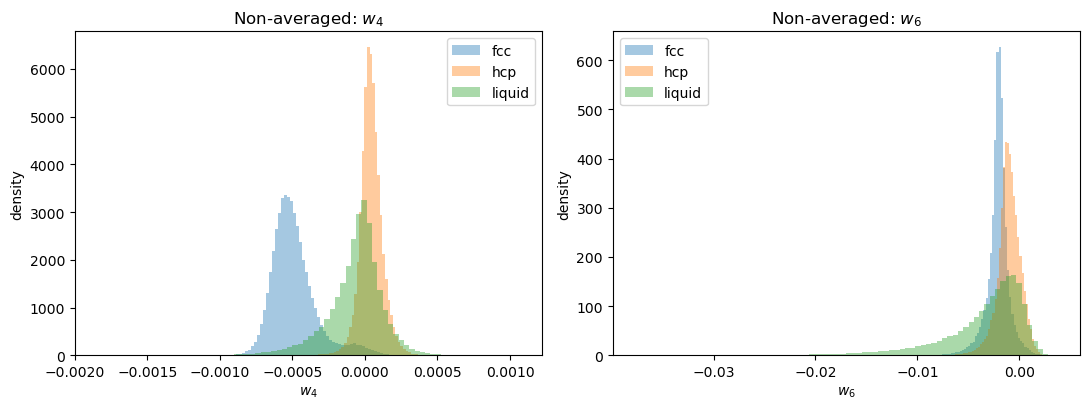

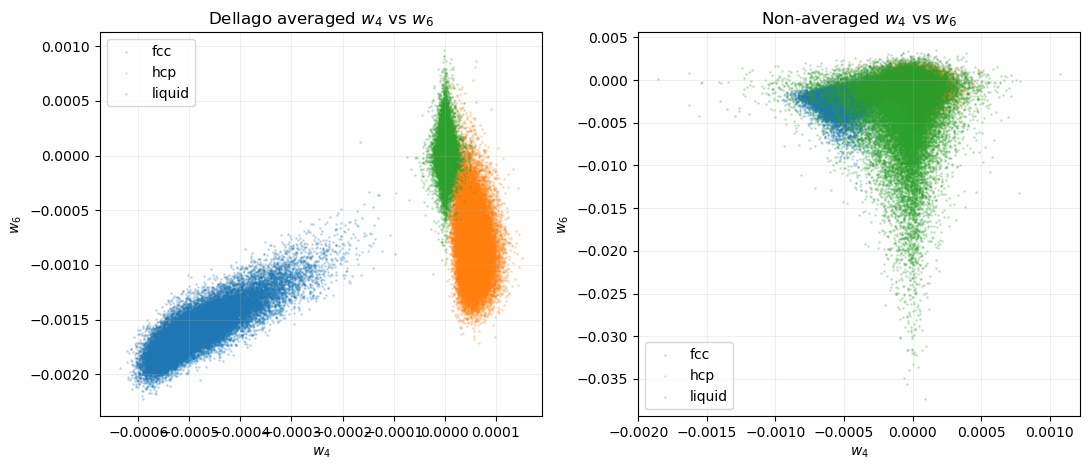

In [55]:
def plot_w4w6_histograms(data_key, title_prefix):
    if not all(data_key in data_by_label[phase] for phase in PHASES):
        print(f"{data_key} is not available for all phases.")
        return

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

    for phase in PHASES:
        lab = LABEL_MAP[phase]
        w4 = data_by_label[phase][data_key][:, 0]
        w6 = data_by_label[phase][data_key][:, 1]

        axes[0].hist(
            w4,
            bins=80,
            density=True,
            alpha=0.4,
            color=LABEL_COLORS[lab],
            label=phase,
        )
        axes[1].hist(
            w6,
            bins=80,
            density=True,
            alpha=0.4,
            color=LABEL_COLORS[lab],
            label=phase,
        )

    axes[0].set_title(f"{title_prefix}: $w_4$")
    axes[0].set_xlabel("$w_4$")
    axes[0].set_ylabel("density")
    axes[0].legend()

    axes[1].set_title(f"{title_prefix}: $w_6$")
    axes[1].set_xlabel("$w_6$")
    axes[1].set_ylabel("density")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def plot_order_scatter_pair(
    averaged_key,
    non_averaged_key,
    x_index,
    y_index,
    x_label,
    y_label,
    averaged_title,
    non_averaged_title,
    max_points_per_phase=30000,
    seed=42,
):
    if not all(averaged_key in data_by_label[phase] for phase in PHASES):
        print(f"{averaged_key} is not available for all phases.")
        return
    if not all(non_averaged_key in data_by_label[phase] for phase in PHASES):
        print(f"{non_averaged_key} is not available for all phases.")
        return

    rng = np.random.default_rng(seed)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))

    for phase in PHASES:
        lab = LABEL_MAP[phase]
        n = data_by_label[phase][averaged_key].shape[0]
        if n > max_points_per_phase:
            idx = rng.choice(n, size=max_points_per_phase, replace=False)
        else:
            idx = np.arange(n)

        averaged = data_by_label[phase][averaged_key][idx]
        non_averaged = data_by_label[phase][non_averaged_key][idx]

        axes[0].scatter(
            averaged[:, x_index],
            averaged[:, y_index],
            s=SCATTER_S,
            alpha=SCATTER_ALPHA,
            color=LABEL_COLORS[lab],
            label=phase,
        )
        axes[1].scatter(
            non_averaged[:, x_index],
            non_averaged[:, y_index],
            s=SCATTER_S,
            alpha=SCATTER_ALPHA,
            color=LABEL_COLORS[lab],
            label=phase,
        )

    axes[0].set_title(averaged_title)
    axes[0].set_xlabel(x_label)
    axes[0].set_ylabel(y_label)
    axes[0].grid(alpha=0.2)
    axes[0].legend()

    axes[1].set_title(non_averaged_title)
    axes[1].set_xlabel(x_label)
    axes[1].set_ylabel(y_label)
    axes[1].grid(alpha=0.2)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


plot_w4w6_histograms("w4w6_no_average", "Non-averaged")
plot_order_scatter_pair(
    averaged_key="w4w6",
    non_averaged_key="w4w6_no_average",
    x_index=0,
    y_index=1,
    x_label="$w_4$",
    y_label="$w_6$",
    averaged_title="Dellago averaged $w_4$ vs $w_6$",
    non_averaged_title="Non-averaged $w_4$ vs $w_6$",
)


## 1c) Simple $w_4/w_6$ rule classification

Rule used here: `fcc` if $w_6 < 0$ and $w_4 \le 0$, `hcp` if $w_6 < 0$ and $w_4 > 0$, otherwise `other`. The same rule is applied once to the Dellago-averaged values and once to the non-averaged values.


,variant,accuracy,balanced_accuracy,fcc_recall,hcp_recall,other_recall
0,Dellago averaged,0.906,0.848,1.000,0.986,0.558
1,Non-averaged,0.669,0.581,0.965,0.639,0.141


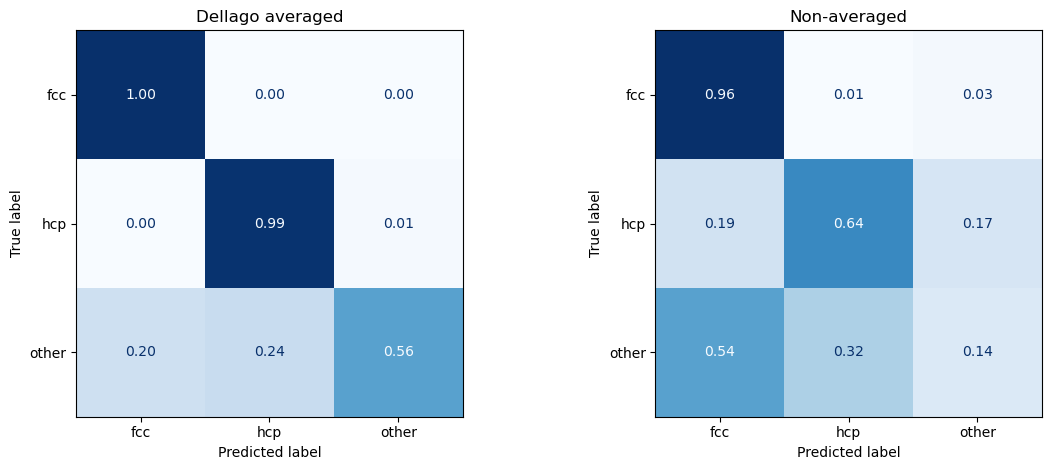

In [56]:
W4W6_RULE_LABELS = ["fcc", "hcp", "other"]


def classify_w4w6_rule(values):
    values = np.asarray(values, dtype=np.float32)
    w4 = values[:, 0]
    w6 = values[:, 1]

    labels = np.full(values.shape[0], "other", dtype=object)
    neg_w6 = w6 < 0
    labels[neg_w6 & (w4 <= 0)] = "fcc"
    labels[neg_w6 & (w4 > 0)] = "hcp"
    return labels


def build_w4w6_rule_dataset(data_by_label, data_key):
    true_labels = []
    pred_labels = []

    for phase in PHASES:
        if data_key not in data_by_label[phase]:
            raise KeyError(f"{data_key} is missing for phase {phase}.")

        values = data_by_label[phase][data_key]
        n_samples = values.shape[0]
        expected = "other" if phase == "liquid" else phase

        true_labels.append(np.full(n_samples, expected, dtype=object))
        pred_labels.append(classify_w4w6_rule(values))

    return np.concatenate(true_labels), np.concatenate(pred_labels)


def summarize_w4w6_rule_results(data_by_label):
    results = []
    confusion_payload = []

    configs = [
        ("w4w6", "Dellago averaged"),
        ("w4w6_no_average", "Non-averaged"),
    ]

    for data_key, label in configs:
        if not all(data_key in data_by_label[phase] for phase in PHASES):
            print(f"Skipping {label}: {data_key} not available for all phases.")
            continue

        y_true, y_pred = build_w4w6_rule_dataset(data_by_label, data_key)
        cm = confusion_matrix(y_true, y_pred, labels=W4W6_RULE_LABELS)
        row_sums = cm.sum(axis=1)
        recall = np.divide(
            np.diag(cm),
            row_sums,
            out=np.zeros(len(W4W6_RULE_LABELS), dtype=float),
            where=row_sums > 0,
        )

        results.append({
            "variant": label,
            "accuracy": accuracy_score(y_true, y_pred),
            "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
            "fcc_recall": recall[0],
            "hcp_recall": recall[1],
            "other_recall": recall[2],
        })
        confusion_payload.append((label, y_true, y_pred))

    results_df = pd.DataFrame(results)
    if not results_df.empty:
        display(results_df.round(3))

    return confusion_payload


def plot_w4w6_rule_confusions(confusion_payload, normalize="true"):
    if not confusion_payload:
        return

    fig, axes = plt.subplots(1, len(confusion_payload), figsize=(6 * len(confusion_payload), 4.8))
    if len(confusion_payload) == 1:
        axes = [axes]

    for ax, (label, y_true, y_pred) in zip(axes, confusion_payload):
        cm = confusion_matrix(y_true, y_pred, labels=W4W6_RULE_LABELS, normalize=normalize)
        disp = ConfusionMatrixDisplay(cm, display_labels=W4W6_RULE_LABELS)
        disp.plot(ax=ax, cmap="Blues", values_format=".2f", colorbar=False)
        ax.set_title(label)
        ax.grid(False)

    plt.tight_layout()
    plt.show()


w4w6_rule_confusions = summarize_w4w6_rule_results(data_by_label)
plot_w4w6_rule_confusions(w4w6_rule_confusions, normalize="true")


## 2) Scatter plots: averaged vs non-averaged $q_4$ vs $q_6$

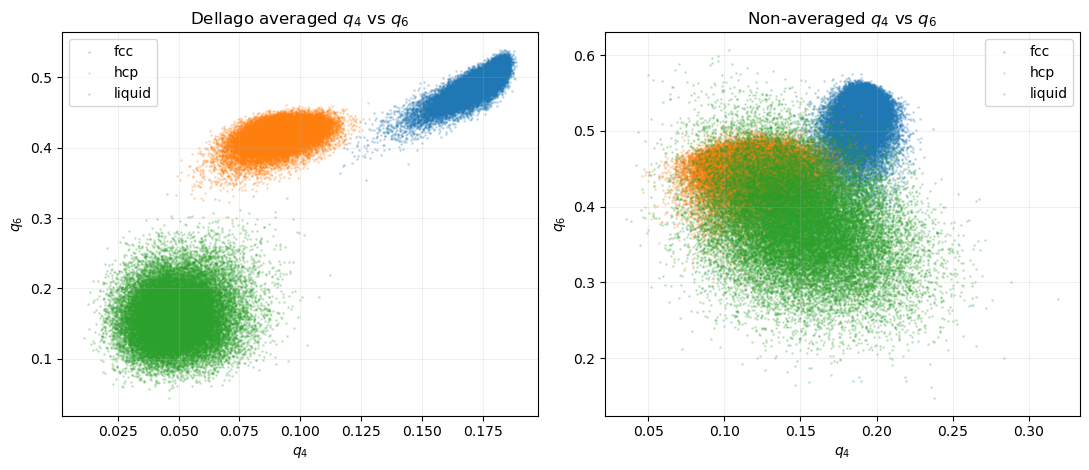

In [57]:
plot_order_scatter_pair(
    averaged_key="ql",
    non_averaged_key="ql_no_average",
    x_index=3,
    y_index=5,
    x_label="$q_4$",
    y_label="$q_6$",
    averaged_title="Dellago averaged $q_4$ vs $q_6$",
    non_averaged_title="Non-averaged $q_4$ vs $q_6$",
)


## 3) PTM/CNA as labeling models

This section evaluates PTM and the CNA variants as direct labelers. The raw structure labels are kept for distribution plots, then collapsed to the current benchmark label space: `fcc`, `hcp`, and `other` for liquid/disordered/non-FCC/non-HCP particles.


The derived `Any Crystal` labeler combines PTM, CNA Adaptive, and CNA Interval: if the crystal votes point to `fcc` or `hcp`, that label is used; all-`other` samples and direct `fcc`/`hcp` ties become `other`.


In [37]:
STRUCTURE_LABELS_FULL = ["fcc", "hcp", "bcc", "ico", "sc", "diamond", "hex_diamond", "graphene", "other"]
EVAL_STRUCTURE_LABELS = ["fcc", "hcp", "other"]

PTM_STRUCTURE_NAMES = {
    0: "other",
    1: "fcc",
    2: "hcp",
    3: "bcc",
    4: "ico",
    5: "sc",
    6: "diamond",
    7: "hex_diamond",
    8: "graphene",
}

CNA_STRUCTURE_NAMES = {
    0: "other",
    1: "fcc",
    2: "hcp",
    3: "bcc",
    4: "ico",
}

STRUCTURE_COLORS = {
    "fcc": "tab:blue",
    "hcp": "tab:orange",
    "bcc": "tab:red",
    "ico": "tab:purple",
    "sc": "tab:brown",
    "diamond": "tab:pink",
    "hex_diamond": "tab:cyan",
    "graphene": "tab:olive",
    "other": "tab:gray",
}

EXPECTED_STRUCTURE_BY_PHASE = {
    "fcc": "fcc",
    "hcp": "hcp",
    "liquid": "other",
}


def decode_structure_values(values, code_to_label):
    values = np.asarray(values)
    labels = np.empty(values.shape, dtype=object)
    for code in np.unique(values.astype(int)):
        labels[values.astype(int) == code] = code_to_label.get(int(code), f"code_{int(code)}")
    return labels


def collapse_to_eval_labels(labels):
    labels = np.asarray(labels, dtype=object)
    collapsed = np.full(labels.shape, "other", dtype=object)
    collapsed[labels == "fcc"] = "fcc"
    collapsed[labels == "hcp"] = "hcp"
    return collapsed


ANY_CRYSTAL_METHODS = ["PTM", "CNA Adaptive", "CNA Interval"]
ANY_CRYSTAL_LABELER_NAME = "Any Crystal (PTM + CNA Adaptive + CNA Interval)"
ANY_CRYSTAL_DENOISED_METHODS = [
    "PTM Denoised",
    "CNA Denoised Adaptive",
    "CNA Denoised Interval",
]
ANY_CRYSTAL_DENOISED_LABELER_NAME = (
    "Any Crystal Denoised (PTM + CNA Adaptive + CNA Interval)"
)


def any_crystal_labeler(method_eval, method_names=ANY_CRYSTAL_METHODS):
    available = [name for name in method_names if name in method_eval]
    if len(available) < 2:
        return None, available

    pred_matrix = np.column_stack([method_eval[name] for name in available])
    fcc_votes = np.sum(pred_matrix == "fcc", axis=1)
    hcp_votes = np.sum(pred_matrix == "hcp", axis=1)

    y_pred = np.full(pred_matrix.shape[0], "other", dtype=object)
    y_pred[fcc_votes > hcp_votes] = "fcc"
    y_pred[hcp_votes > fcc_votes] = "hcp"

    return y_pred, available


def build_structure_label_data(data_by_label):
    true_phase = []
    true_eval = []
    method_raw = {}

    for phase in PHASES:
        data = data_by_label[phase]
        n_samples = data["dist"].shape[0]
        true_phase.append(np.full(n_samples, phase, dtype=object))
        true_eval.append(np.full(n_samples, EXPECTED_STRUCTURE_BY_PHASE[phase], dtype=object))

        if "ptm" in data:
            ptm_labels = decode_structure_values(data["ptm"][:, 0], PTM_STRUCTURE_NAMES)
            method_raw.setdefault("PTM", []).append(ptm_labels)

        if "cna" in data:
            cna = data["cna"]
            cna_columns = data.get("cna_columns", np.array([f"cna_{i}" for i in range(cna.shape[1])]))
            for col_idx, col_name in enumerate(cna_columns):
                col_text = str(col_name).replace("cna_", "").replace("_", " ")
                method_name = f"CNA {col_text.title()}"
                cna_labels = decode_structure_values(cna[:, col_idx], CNA_STRUCTURE_NAMES)
                method_raw.setdefault(method_name, []).append(cna_labels)

        if "ptm_denoised" in data:
            ptm_denoised_labels = decode_structure_values(
                data["ptm_denoised"][:, 0],
                PTM_STRUCTURE_NAMES,
            )
            method_raw.setdefault("PTM Denoised", []).append(ptm_denoised_labels)

        if "cna_denoised" in data:
            cna_denoised = data["cna_denoised"]
            cna_denoised_columns = data.get(
                "cna_denoised_columns",
                np.array([f"cna_denoised_{i}" for i in range(cna_denoised.shape[1])]),
            )
            for col_idx, col_name in enumerate(cna_denoised_columns):
                col_text = str(col_name).replace("cna_", "").replace("_", " ")
                method_name = f"CNA Denoised {col_text.title()}"
                cna_labels = decode_structure_values(
                    cna_denoised[:, col_idx],
                    CNA_STRUCTURE_NAMES,
                )
                method_raw.setdefault(method_name, []).append(cna_labels)

    true_phase = np.concatenate(true_phase)
    true_eval = np.concatenate(true_eval)

    complete_method_raw = {}
    for method, parts in method_raw.items():
        if len(parts) == len(PHASES):
            complete_method_raw[method] = np.concatenate(parts)
        else:
            print(
                f"Skipping {method}: found labels for {len(parts)}/{len(PHASES)} phases. "
                "Regenerate all phase particle_data.npz files before evaluating it."
            )

    method_eval = {
        method: collapse_to_eval_labels(labels)
        for method, labels in complete_method_raw.items()
    }

    any_crystal_labels, any_crystal_methods = any_crystal_labeler(method_eval)
    if any_crystal_labels is not None:
        method_eval[ANY_CRYSTAL_LABELER_NAME] = any_crystal_labels
        complete_method_raw[ANY_CRYSTAL_LABELER_NAME] = any_crystal_labels
        print(
            f"Added {ANY_CRYSTAL_LABELER_NAME} from: "
            + ", ".join(any_crystal_methods)
        )

    any_denoised_labels, any_denoised_methods = any_crystal_labeler(
        method_eval,
        method_names=ANY_CRYSTAL_DENOISED_METHODS,
    )
    if any_denoised_labels is not None:
        method_eval[ANY_CRYSTAL_DENOISED_LABELER_NAME] = any_denoised_labels
        complete_method_raw[ANY_CRYSTAL_DENOISED_LABELER_NAME] = any_denoised_labels
        print(
            f"Added {ANY_CRYSTAL_DENOISED_LABELER_NAME} from: "
            + ", ".join(any_denoised_methods)
        )

    return true_phase, true_eval, complete_method_raw, method_eval


true_phase_labels, true_structure_labels, method_raw_labels, method_eval_labels = build_structure_label_data(data_by_label)

print(f"Samples available for PTM/CNA evaluation: {len(true_structure_labels)}")
if method_eval_labels:
    print("Available labelers:", ", ".join(method_eval_labels))
else:
    print("No PTM/CNA labels found in the loaded particle_data.npz files yet.")


Added Any Crystal (PTM + CNA Adaptive + CNA Interval) from: PTM, CNA Adaptive, CNA Interval
Samples available for PTM/CNA evaluation: 450900
Available labelers: PTM, CNA Fixed, CNA Adaptive, CNA Interval, Any Crystal (PTM + CNA Adaptive + CNA Interval)


### 3a) Structure-label distributions by true phase


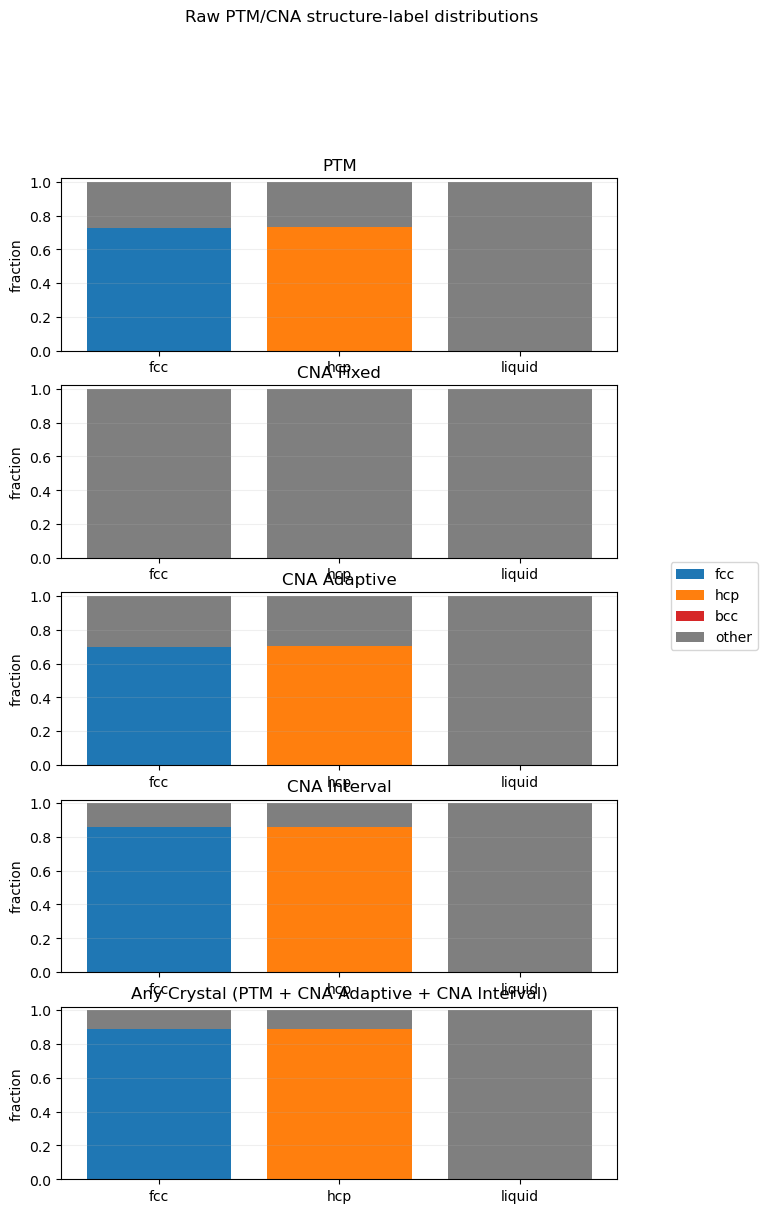

No matching PTM/CNA labels to plot.


In [21]:
def plot_structure_distributions_by_phase(
    method_raw_labels,
    true_phase_labels,
    normalize=True,
    methods=None,
    title=None,
):
    if not method_raw_labels:
        print("No PTM/CNA labels to plot.")
        return

    if methods is None:
        methods = list(method_raw_labels)
    else:
        methods = [method for method in methods if method in method_raw_labels]

    if not methods:
        print("No matching PTM/CNA labels to plot.")
        return

    fig, axes = plt.subplots(
        len(methods),
        1,
        figsize=(8, max(3.0, 2.6 * len(methods))),
        squeeze=False,
    )

    for ax, method in zip(axes[:, 0], methods):
        labels = method_raw_labels[method]
        present = [label for label in STRUCTURE_LABELS_FULL if np.any(labels == label)]
        extra = sorted(set(labels) - set(present))
        plot_labels = present + extra

        bottom = np.zeros(len(PHASES), dtype=float)
        for structure_label in plot_labels:
            values = np.array([
                np.sum(labels[true_phase_labels == phase] == structure_label)
                for phase in PHASES
            ], dtype=float)
            if normalize:
                totals = np.array([
                    np.sum(true_phase_labels == phase)
                    for phase in PHASES
                ], dtype=float)
                values = np.divide(values, totals, out=np.zeros_like(values), where=totals > 0)

            ax.bar(
                PHASES,
                values,
                bottom=bottom,
                label=structure_label,
                color=STRUCTURE_COLORS.get(structure_label, "black"),
            )
            bottom += values

        ax.set_title(method)
        ax.set_ylabel("fraction" if normalize else "count")
        ax.set_ylim(0, 1.02 if normalize else None)
        ax.grid(axis="y", alpha=0.2)

    if title:
        fig.suptitle(title, y=1.01)

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="center right")
    fig.subplots_adjust(right=0.82)
    plt.show()


raw_distribution_methods = [
    method for method in method_raw_labels
    if "Denoised" not in method
]
denoised_distribution_methods = [
    method for method in method_raw_labels
    if "Denoised" in method
]

plot_structure_distributions_by_phase(
    method_raw_labels,
    true_phase_labels,
    normalize=True,
    methods=raw_distribution_methods,
    title="Raw PTM/CNA structure-label distributions",
)
plot_structure_distributions_by_phase(
    method_raw_labels,
    true_phase_labels,
    normalize=True,
    methods=denoised_distribution_methods,
    title="Denoised PTM/CNA structure-label distributions",
)


### 3b) Raw restricted-PTM class confidence by true phase

The restricted PTM preprocessing reruns PTM with one candidate structure enabled at a time. Lower RMSD means a better match to that candidate. The plots below convert these RMSDs into soft, RMSD-derived confidence values for easier comparison across candidate structures. These are not calibrated probabilities.


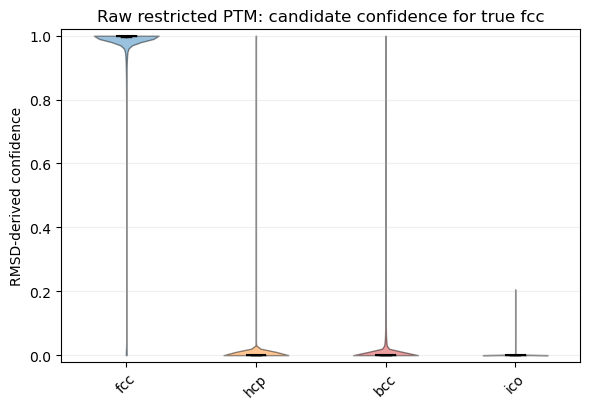

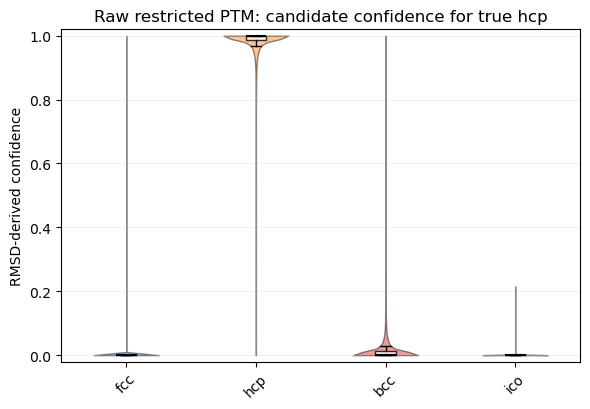

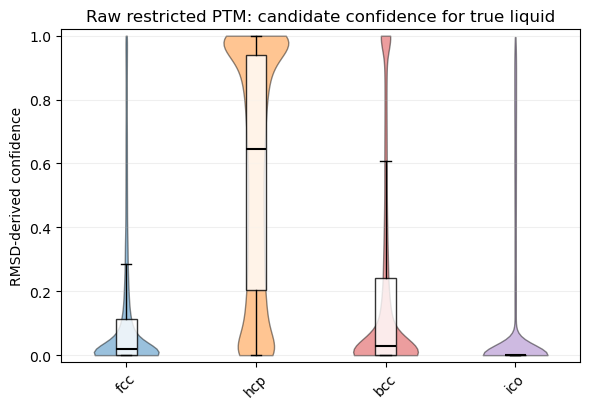

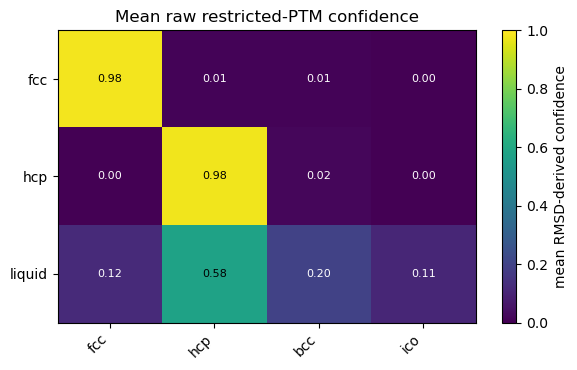

In [22]:
PTM_CONFIDENCE_TAU = 0.02


def sampled_values(values, max_points=30000, seed=42):
    values = np.asarray(values, dtype=np.float32)
    values = values[np.isfinite(values)]
    if values.size <= max_points:
        return values

    rng = np.random.default_rng(seed)
    idx = rng.choice(values.size, size=max_points, replace=False)
    return values[idx]


def ptm_rmsd_to_confidence(rmsd_by_type, tau=PTM_CONFIDENCE_TAU):
    rmsd = np.asarray(rmsd_by_type, dtype=np.float32)
    confidence = np.full_like(rmsd, np.nan, dtype=np.float32)

    finite = np.isfinite(rmsd)
    has_match = np.any(finite, axis=1)
    if not np.any(has_match):
        return confidence

    valid_rmsd = rmsd[has_match]
    valid_finite = finite[has_match]
    row_min = np.nanmin(valid_rmsd, axis=1, keepdims=True)

    shifted = valid_rmsd - row_min
    scores = np.exp(-shifted / float(tau))
    scores[~valid_finite] = 0.0
    score_sum = np.sum(scores, axis=1, keepdims=True)

    valid_confidence = np.divide(
        scores,
        score_sum,
        out=np.full_like(scores, np.nan, dtype=np.float32),
        where=score_sum > 0,
    )
    confidence[has_match] = valid_confidence
    return confidence


def get_ptm_type_names(data_by_label, type_names_key, rmsd_key):
    type_names = list(data_by_label[PHASES[0]].get(type_names_key, []))
    if not type_names:
        n_types = data_by_label[PHASES[0]][rmsd_key].shape[1]
        type_names = [f"type_{i}" for i in range(n_types)]
    return [str(name) for name in type_names]


def plot_ptm_type_confidence_by_phase(
    data_by_label,
    rmsd_key="ptm_rmsd_by_type",
    type_names_key="ptm_rmsd_type_names",
    title_prefix="Raw restricted PTM",
    tau=PTM_CONFIDENCE_TAU,
    max_points=30000,
):
    if not all(rmsd_key in data_by_label[phase] for phase in PHASES):
        print(f"{title_prefix}: required field '{rmsd_key}' is not available yet.")
        return

    type_names = get_ptm_type_names(data_by_label, type_names_key, rmsd_key)

    for phase in PHASES:
        confidence = ptm_rmsd_to_confidence(data_by_label[phase][rmsd_key], tau=tau)
        values = [
            sampled_values(
                confidence[:, type_idx],
                max_points=max_points,
                seed=400 + type_idx,
            )
            for type_idx in range(confidence.shape[1])
        ]

        plt.figure(figsize=(max(6, 0.9 * len(type_names)), 4.2))
        parts = plt.violinplot(
            values,
            positions=np.arange(len(type_names)),
            showmeans=False,
            showmedians=False,
            showextrema=False,
        )
        for body, label in zip(parts["bodies"], type_names):
            body.set_facecolor(STRUCTURE_COLORS.get(label, "tab:gray"))
            body.set_edgecolor("black")
            body.set_alpha(0.45)

        plt.boxplot(
            values,
            positions=np.arange(len(type_names)),
            widths=0.16,
            showfliers=False,
            patch_artist=True,
            boxprops={"facecolor": "white", "edgecolor": "black", "alpha": 0.8},
            medianprops={"color": "black", "linewidth": 1.5},
            whiskerprops={"color": "black"},
            capprops={"color": "black"},
        )

        plt.xticks(np.arange(len(type_names)), type_names, rotation=45)
        plt.ylabel("RMSD-derived confidence")
        plt.ylim(-0.02, 1.02)
        plt.title(f"{title_prefix}: candidate confidence for true {phase}")
        plt.grid(axis="y", alpha=0.2)
        plt.tight_layout()
        plt.show()


def plot_ptm_type_confidence_heatmap(
    data_by_label,
    rmsd_key="ptm_rmsd_by_type",
    type_names_key="ptm_rmsd_type_names",
    title="Mean raw restricted-PTM confidence",
    tau=PTM_CONFIDENCE_TAU,
):
    if not all(rmsd_key in data_by_label[phase] for phase in PHASES):
        print(f"{title}: required field '{rmsd_key}' is not available yet.")
        return

    type_names = get_ptm_type_names(data_by_label, type_names_key, rmsd_key)
    means = []
    for phase in PHASES:
        confidence = ptm_rmsd_to_confidence(data_by_label[phase][rmsd_key], tau=tau)
        means.append(np.nanmean(confidence, axis=0))
    means = np.vstack(means)

    fig, ax = plt.subplots(figsize=(max(6, 0.8 * len(type_names)), 3.8))
    im = ax.imshow(means, vmin=0, vmax=1, cmap="viridis", aspect="auto")
    ax.set_xticks(np.arange(len(type_names)))
    ax.set_xticklabels(type_names, rotation=45, ha="right")
    ax.set_yticks(np.arange(len(PHASES)))
    ax.set_yticklabels(PHASES)
    ax.set_title(title)

    for row_idx in range(means.shape[0]):
        for col_idx in range(means.shape[1]):
            ax.text(
                col_idx,
                row_idx,
                f"{means[row_idx, col_idx]:.2f}",
                ha="center",
                va="center",
                color="white" if means[row_idx, col_idx] < 0.5 else "black",
                fontsize=8,
            )

    fig.colorbar(im, ax=ax, label="mean RMSD-derived confidence")
    plt.tight_layout()
    plt.show()


plot_ptm_type_confidence_by_phase(
    data_by_label,
    rmsd_key="ptm_rmsd_by_type",
    type_names_key="ptm_rmsd_type_names",
    title_prefix="Raw restricted PTM",
)
plot_ptm_type_confidence_heatmap(
    data_by_label,
    rmsd_key="ptm_rmsd_by_type",
    type_names_key="ptm_rmsd_type_names",
    title="Mean raw restricted-PTM confidence",
)


### 3c) Denoised restricted-PTM class confidence by true phase

This repeats the restricted-PTM confidence visualization using the denoised trajectory outputs, if present. It should be compared directly against the raw restricted-PTM plots above to see whether denoising improves crystal confidence without pushing liquid particles into crystalline classes.


In [23]:
plot_ptm_type_confidence_by_phase(
    data_by_label,
    rmsd_key="ptm_denoised_rmsd_by_type",
    type_names_key="ptm_denoised_rmsd_type_names",
    title_prefix="Denoised restricted PTM",
)
plot_ptm_type_confidence_heatmap(
    data_by_label,
    rmsd_key="ptm_denoised_rmsd_by_type",
    type_names_key="ptm_denoised_rmsd_type_names",
    title="Mean denoised restricted-PTM confidence",
)


Denoised restricted PTM: required field 'ptm_denoised_rmsd_by_type' is not available yet.
Mean denoised restricted-PTM confidence: required field 'ptm_denoised_rmsd_by_type' is not available yet.


### 3d) Vanilla PTM/CNA classifier performance

For this benchmark, `liquid` is treated as `other`. Any PTM/CNA prediction that is not `fcc` or `hcp` is also collapsed to `other`.


In [24]:
def print_table(rows, columns, title=None, float_digits=3):
    if title:
        print(title)
    if not rows:
        print("  no rows")
        return

    formatted_rows = []
    for row in rows:
        formatted = []
        for col in columns:
            value = row.get(col, "")
            if isinstance(value, float):
                if np.isnan(value):
                    formatted.append("nan")
                else:
                    formatted.append(f"{value:.{float_digits}f}")
            else:
                formatted.append(str(value))
        formatted_rows.append(formatted)

    widths = [
        max(len(str(col)), *(len(row[i]) for row in formatted_rows))
        for i, col in enumerate(columns)
    ]
    header = "  ".join(str(col).ljust(widths[i]) for i, col in enumerate(columns))
    print(header)
    print("  ".join("-" * width for width in widths))
    for row in formatted_rows:
        print("  ".join(row[i].ljust(widths[i]) for i in range(len(columns))))


def evaluate_vanilla_labelers(true_structure_labels, method_eval_labels):
    rows = []
    per_class_rows = []

    for method, y_pred in method_eval_labels.items():
        rows.append({
            "method": method,
            "accuracy": accuracy_score(true_structure_labels, y_pred),
            "balanced_accuracy": balanced_accuracy_score(true_structure_labels, y_pred),
            "macro_f1": f1_score(
                true_structure_labels,
                y_pred,
                labels=EVAL_STRUCTURE_LABELS,
                average="macro",
                zero_division=0,
            ),
        })

        report = classification_report(
            true_structure_labels,
            y_pred,
            labels=EVAL_STRUCTURE_LABELS,
            target_names=EVAL_STRUCTURE_LABELS,
            zero_division=0,
            output_dict=True,
        )
        for label in EVAL_STRUCTURE_LABELS:
            per_class_rows.append({
                "method": method,
                "class": label,
                "precision": report[label]["precision"],
                "recall": report[label]["recall"],
                "f1": report[label]["f1-score"],
                "support": int(report[label]["support"]),
            })

    rows = sorted(rows, key=lambda row: row["balanced_accuracy"], reverse=True)
    return rows, per_class_rows


vanilla_metric_rows, vanilla_per_class_rows = evaluate_vanilla_labelers(
    true_structure_labels,
    method_eval_labels,
)

print_table(
    vanilla_metric_rows,
    ["method", "accuracy", "balanced_accuracy", "macro_f1"],
    title="Vanilla labeler ranking",
)
print()
print_table(
    vanilla_per_class_rows,
    ["method", "class", "precision", "recall", "f1", "support"],
    title="Per-class metrics",
)


Vanilla labeler ranking
method                                           accuracy  balanced_accuracy  macro_f1
-----------------------------------------------  --------  -----------------  --------
Any Crystal (PTM + CNA Adaptive + CNA Interval)  0.911     0.926              0.900   
CNA Interval                                     0.886     0.905              0.875   
PTM                                              0.783     0.819              0.778   
CNA Adaptive                                     0.760     0.800              0.757   
CNA Fixed                                        0.200     0.333              0.111   

Per-class metrics
method                                           class  precision  recall  f1     support
-----------------------------------------------  -----  ---------  ------  -----  -------
PTM                                              fcc    1.000      0.726   0.841  180300 
PTM                                              hcp    1.000      0.732   0.8

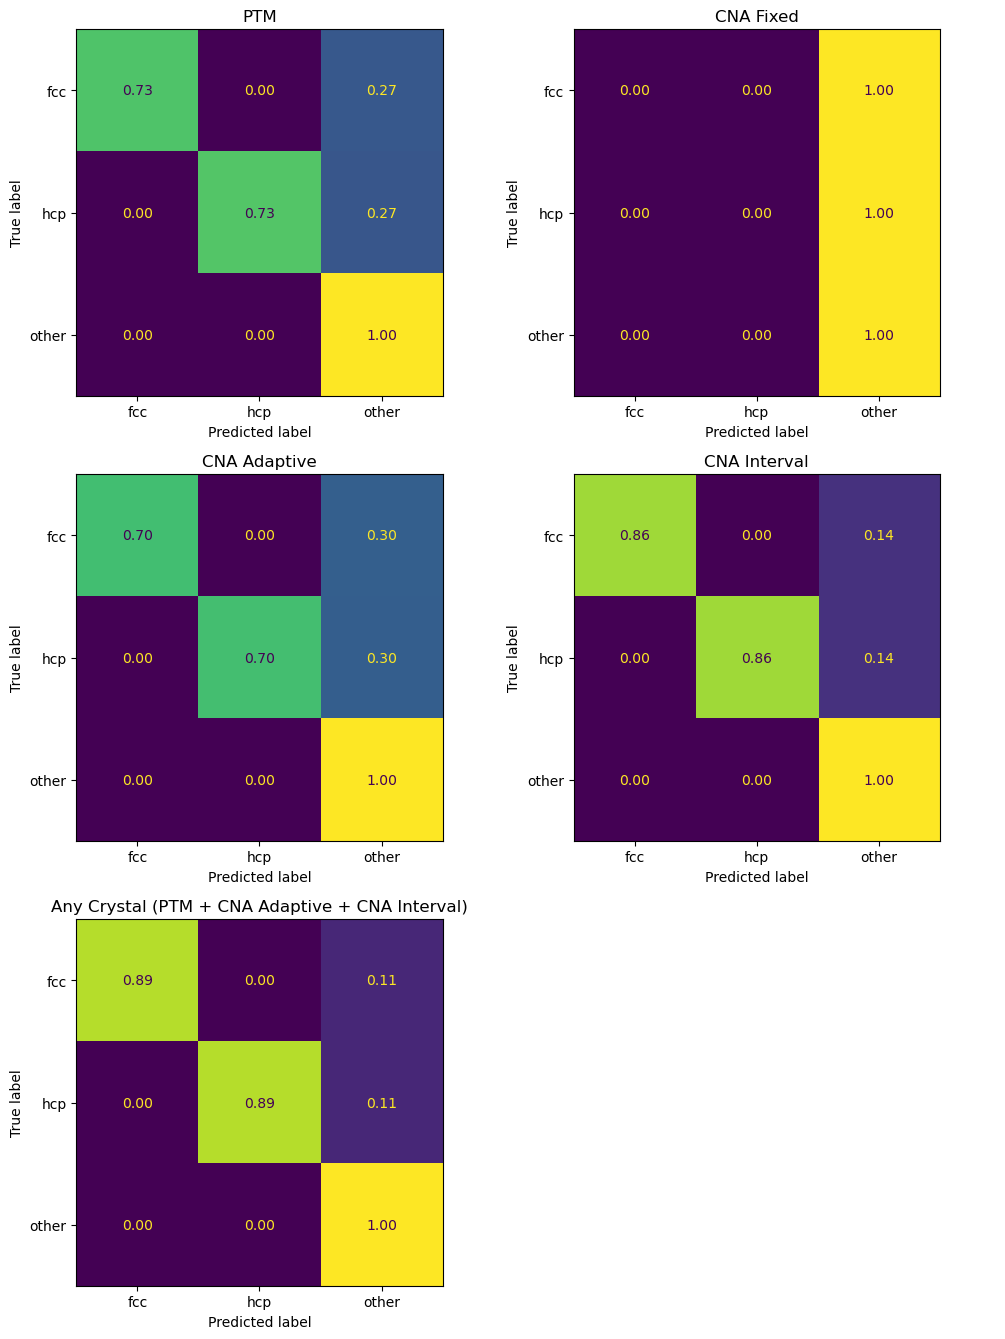

In [25]:
def plot_vanilla_confusion_matrices(true_structure_labels, method_eval_labels, normalize="true"):
    if not method_eval_labels:
        print("No PTM/CNA labels to evaluate.")
        return

    methods = list(method_eval_labels)
    n_cols = 2
    n_rows = int(np.ceil(len(methods) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.2 * n_cols, 4.5 * n_rows))
    axes = np.asarray(axes).reshape(-1)

    for ax, method in zip(axes, methods):
        y_pred = method_eval_labels[method]
        cm = confusion_matrix(
            true_structure_labels,
            y_pred,
            labels=EVAL_STRUCTURE_LABELS,
            normalize=normalize,
        )
        disp = ConfusionMatrixDisplay(cm, display_labels=EVAL_STRUCTURE_LABELS)
        disp.plot(ax=ax, values_format=".2f" if normalize else "d", colorbar=False)
        ax.set_title(method)

    for ax in axes[len(methods):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


plot_vanilla_confusion_matrices(true_structure_labels, method_eval_labels, normalize="true")


### 3e) Agreement-based labeling rules

These rules evaluate the practical tradeoff between coverage and accepted-label accuracy. Single-method rows keep all particles. Agreement rows reject particles where the selected methods disagree.


In [26]:
def majority_vote(pred_matrix):
    winners = np.empty(pred_matrix.shape[0], dtype=object)
    winner_counts = np.zeros(pred_matrix.shape[0], dtype=int)
    ties = np.zeros(pred_matrix.shape[0], dtype=bool)

    for i, row in enumerate(pred_matrix):
        counts = {label: int(np.sum(row == label)) for label in EVAL_STRUCTURE_LABELS}
        best_count = max(counts.values())
        best_labels = [label for label, count in counts.items() if count == best_count]
        winners[i] = best_labels[0]
        winner_counts[i] = best_count
        ties[i] = len(best_labels) > 1

    return winners, winner_counts, ties


def evaluate_labeling_rule(name, y_true, y_pred, accept_mask):
    accept_mask = np.asarray(accept_mask, dtype=bool)
    n_total = len(y_true)
    n_accepted = int(np.sum(accept_mask))
    coverage = n_accepted / n_total if n_total else np.nan

    if n_accepted == 0:
        return {
            "rule": name,
            "coverage": coverage,
            "accepted_accuracy": np.nan,
            "accepted_balanced_accuracy": np.nan,
            "accepted_macro_f1": np.nan,
            "n_accepted": n_accepted,
        }

    yt = y_true[accept_mask]
    yp = y_pred[accept_mask]
    return {
        "rule": name,
        "coverage": coverage,
        "accepted_accuracy": accuracy_score(yt, yp),
        "accepted_balanced_accuracy": balanced_accuracy_score(yt, yp),
        "accepted_macro_f1": f1_score(
            yt,
            yp,
            labels=EVAL_STRUCTURE_LABELS,
            average="macro",
            zero_division=0,
        ),
        "n_accepted": n_accepted,
    }


def build_agreement_rule_results(true_structure_labels, method_eval_labels):
    if not method_eval_labels:
        return [], None, None

    rows = []
    method_names = list(method_eval_labels)

    for method in method_names:
        y_pred = method_eval_labels[method]
        rows.append(
            evaluate_labeling_rule(
                method,
                true_structure_labels,
                y_pred,
                np.ones_like(true_structure_labels, dtype=bool),
            )
        )

    for i, left in enumerate(method_names):
        for right in method_names[i + 1:]:
            pred_left = method_eval_labels[left]
            pred_right = method_eval_labels[right]
            accept = pred_left == pred_right
            rows.append(
                evaluate_labeling_rule(
                    f"{left} == {right}",
                    true_structure_labels,
                    pred_left,
                    accept,
                )
            )

    pred_matrix = np.column_stack([method_eval_labels[name] for name in method_names])
    vote_pred, vote_count, vote_ties = majority_vote(pred_matrix)

    rows.append(
        evaluate_labeling_rule(
            "majority vote, no tie",
            true_structure_labels,
            vote_pred,
            ~vote_ties,
        )
    )

    for min_votes in range(2, len(method_names) + 1):
        rows.append(
            evaluate_labeling_rule(
                f"agreement confidence >= {min_votes}/{len(method_names)}",
                true_structure_labels,
                vote_pred,
                (vote_count >= min_votes) & (~vote_ties),
            )
        )

    rows = sorted(
        rows,
        key=lambda row: (
            -np.nan_to_num(row["accepted_accuracy"], nan=-1.0),
            -row["coverage"],
        ),
    )
    agreement_confidence = vote_count / len(method_names)
    return rows, vote_pred, agreement_confidence


agreement_rule_rows, agreement_vote_labels, agreement_confidence = build_agreement_rule_results(
    true_structure_labels,
    method_eval_labels,
)

print_table(
    agreement_rule_rows,
    [
        "rule",
        "coverage",
        "accepted_accuracy",
        "accepted_balanced_accuracy",
        "accepted_macro_f1",
        "n_accepted",
    ],
    title="Coverage vs accepted-label quality",
)


Coverage vs accepted-label quality
rule                                                             coverage  accepted_accuracy  accepted_balanced_accuracy  accepted_macro_f1  n_accepted
---------------------------------------------------------------  --------  -----------------  --------------------------  -----------------  ----------
Any Crystal (PTM + CNA Adaptive + CNA Interval)                  1.000     0.911              0.926                       0.900              450900    
CNA Interval == Any Crystal (PTM + CNA Adaptive + CNA Interval)  0.975     0.908              0.923                       0.899              439669    
PTM == Any Crystal (PTM + CNA Adaptive + CNA Interval)           0.872     0.898              0.912                       0.892              393209    
CNA Adaptive == Any Crystal (PTM + CNA Adaptive + CNA Interval)  0.849     0.895              0.908                       0.890              382657    
PTM == CNA Interval                                  

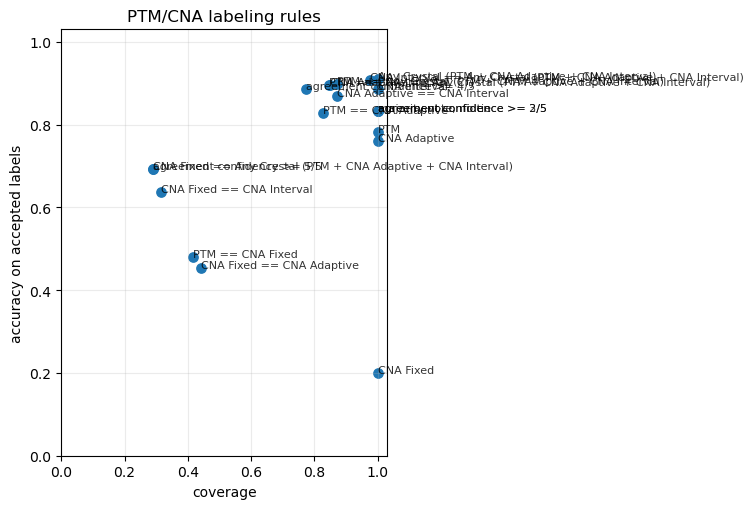

In [27]:
def plot_coverage_vs_accuracy(rule_rows):
    if not rule_rows:
        print("No agreement rules to plot.")
        return

    coverage = np.array([row["coverage"] for row in rule_rows], dtype=float)
    accuracy = np.array([row["accepted_accuracy"] for row in rule_rows], dtype=float)
    names = [row["rule"] for row in rule_rows]

    plt.figure(figsize=(7.5, 5.2))
    plt.scatter(coverage, accuracy, s=45)
    for x, y, name in zip(coverage, accuracy, names):
        if np.isfinite(x) and np.isfinite(y):
            plt.annotate(name, (x, y), fontsize=8, alpha=0.8)

    plt.xlabel("coverage")
    plt.ylabel("accuracy on accepted labels")
    plt.xlim(0, 1.03)
    plt.ylim(0, 1.03)
    plt.grid(alpha=0.25)
    plt.title("PTM/CNA labeling rules")
    plt.tight_layout()
    plt.show()


plot_coverage_vs_accuracy(agreement_rule_rows)


## 4) Simple shallow autoencoder in PyTorch


In [18]:
class ShallowAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=2):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, latent_dim),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, input_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        x_rec = self.decoder(z)
        return x_rec

    def encode(self, x):
        return self.encoder(x)


## 5) Helpers for data preparation, training, plotting, and classification


In [ ]:
def make_ae_data(data_kind, selected_phases, balance=True, seed=42):
    rng = np.random.default_rng(seed)

    Xs = []
    ys = []
    q4s = []
    q6s = []

    # first collect raw arrays phase by phase
    raw = {}
    for phase in selected_phases:
        X = data_by_label[phase][data_kind]

        if data_kind == "vec_dist":
            X = X.reshape(X.shape[0], -1)
        else:
            X = X.reshape(X.shape[0], -1)

        q4 = data_by_label[phase]["ql"][:, 3]
        q6 = data_by_label[phase]["ql"][:, 5]

        raw[phase] = {
            "X": X,
            "q4": q4,
            "q6": q6
        }

    # optionally balance by downsampling all phases to the smallest size
    if balance:
        min_count = min(raw[phase]["X"].shape[0] for phase in selected_phases)
        print(f"Balancing classes to {min_count} samples each")

        for phase in selected_phases:
            n = raw[phase]["X"].shape[0]
            idx = rng.choice(n, size=min_count, replace=False)

            X = raw[phase]["X"][idx]
            q4 = raw[phase]["q4"][idx]
            q6 = raw[phase]["q6"][idx]
            y = np.full(X.shape[0], LABEL_MAP[phase], dtype=int)

            Xs.append(X)
            ys.append(y)
            q4s.append(q4)
            q6s.append(q6)
    else:
        for phase in selected_phases:
            X = raw[phase]["X"]
            q4 = raw[phase]["q4"]
            q6 = raw[phase]["q6"]
            y = np.full(X.shape[0], LABEL_MAP[phase], dtype=int)

            Xs.append(X)
            ys.append(y)
            q4s.append(q4)
            q6s.append(q6)

    X = np.concatenate(Xs, axis=0).astype(np.float32)
    y = np.concatenate(ys, axis=0)
    q4 = np.concatenate(q4s, axis=0).astype(np.float32)
    q6 = np.concatenate(q6s, axis=0).astype(np.float32)

    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X).astype(np.float32)

    return X_scaled, y, q4, q6, scaler


def train_shallow_ae(X, y, latent_dim=2, epochs=50, batch_size=256, lr=1e-3):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y,
        shuffle=True
    )

    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    X_test_t  = torch.tensor(X_test, dtype=torch.float32)

    train_loader = DataLoader(
        TensorDataset(X_train_t, X_train_t),
        batch_size=batch_size,
        shuffle=True
    )
    val_loader = DataLoader(
        TensorDataset(X_test_t, X_test_t),
        batch_size=batch_size,
        shuffle=False
    )

    model = ShallowAutoencoder(input_dim=X.shape[1], latent_dim=latent_dim).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    hist = {"loss": [], "val_loss": []}

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        for xb, target in train_loader:
            xb = xb.to(DEVICE)
            target = target.to(DEVICE)

            opt.zero_grad()
            pred = model(xb)
            loss = criterion(pred, target)
            loss.backward()
            opt.step()

            train_loss += loss.item() * xb.size(0)

        train_loss /= len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, target in val_loader:
                xb = xb.to(DEVICE)
                target = target.to(DEVICE)
                pred = model(xb)
                loss = criterion(pred, target)
                val_loss += loss.item() * xb.size(0)

        val_loss /= len(val_loader.dataset)

        hist["loss"].append(train_loss)
        hist["val_loss"].append(val_loss)

    model.eval()
    with torch.no_grad():
        X_t = torch.tensor(X, dtype=torch.float32).to(DEVICE)
        Z = model.encode(X_t).cpu().numpy()

    return model, hist, Z


def plot_ae_row(results_dict, selected_phases, title_prefix):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
    kinds = ["dist", "vec_dist", "ql"]
    nice_titles = {"dist": "distances", "vec_dist": "vectors", "ql": "qls"}

    for ax, kind in zip(axes, kinds):
        Z = results_dict[kind]["Z"]
        y = results_dict[kind]["y"]

        if Z.shape[1] > 2:
            Z_plot = PCA(n_components=2).fit_transform(Z)
        else:
            Z_plot = Z

        for phase in selected_phases:
            lab = LABEL_MAP[phase]
            mask = (y == lab)
            ax.scatter(
                Z_plot[mask, 0],
                Z_plot[mask, 1],
                s=SCATTER_S,
                alpha=SCATTER_ALPHA,
                color=LABEL_COLORS[lab],
                label=phase
            )

        ax.set_title(f"{title_prefix}: {nice_titles[kind]}")
        ax.set_xlabel("z1 / PC1")
        ax.set_ylabel("z2 / PC2")
        ax.grid(alpha=0.2)

    handles, labels = axes[0].get_legend_handles_labels()
    axes[0].legend(handles, labels)
    plt.tight_layout()
    plt.show()

def run_classifier_on_latent(Z, y, title):
    X_train, X_test, y_train, y_test = train_test_split(
        Z, y,
        test_size=0.2,
        random_state=42,
        stratify=y,
        shuffle=True
    )

    clf = LogisticRegression(max_iter=5000)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    present_labels = sorted(np.unique(y))
    target_names = [LABEL_NAMES[i] for i in present_labels]

    print(title)
    print(classification_report(y_test, y_pred, labels=present_labels, target_names=target_names))

    cm = confusion_matrix(y_test, y_pred, labels=present_labels)
    disp = ConfusionMatrixDisplay(cm, display_labels=target_names)
    disp.plot()
    plt.title(title)
    plt.tight_layout()
    plt.show()


## 6) Autoencoder for `liquid` vs `fcc`


In [20]:
selected_phases_2 = ["liquid", "fcc"]
ae_results_2 = {}

for kind in ["dist", "vec_dist", "ql"]:
    X_ae, y_ae, q4_ae, q6_ae, scaler = make_ae_data(kind, selected_phases_2)
    model, hist, Z = train_shallow_ae(
        X_ae, y_ae,
        latent_dim=LATENT_DIM,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        lr=LR
    )

    ae_results_2[kind] = {
        "X": X_ae,
        "y": y_ae,
        "q4": q4_ae,
        "q6": q6_ae,
        "scaler": scaler,
        "model": model,
        "history": hist,
        "Z": Z
    }


Balancing classes to 90300 samples each
Balancing classes to 90300 samples each
Balancing classes to 90300 samples each


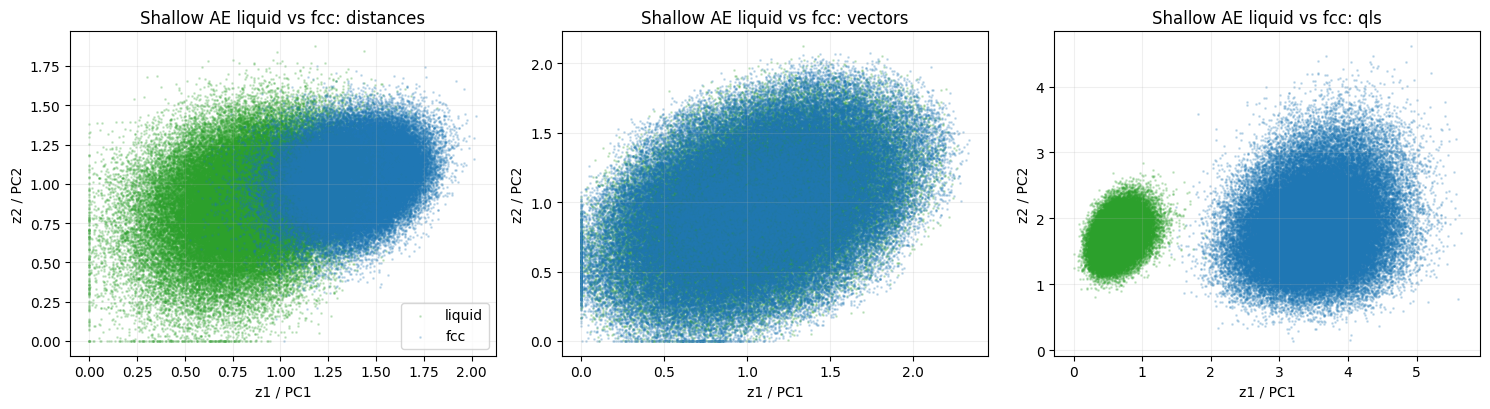

In [31]:
plot_ae_row(ae_results_2, selected_phases_2, "Shallow AE liquid vs fcc")

Classifier on bottleneck | liquid vs fcc | dist
              precision    recall  f1-score   support

         fcc       0.88      0.90      0.89     18060
      liquid       0.90      0.88      0.89     18060

    accuracy                           0.89     36120
   macro avg       0.89      0.89      0.89     36120
weighted avg       0.89      0.89      0.89     36120



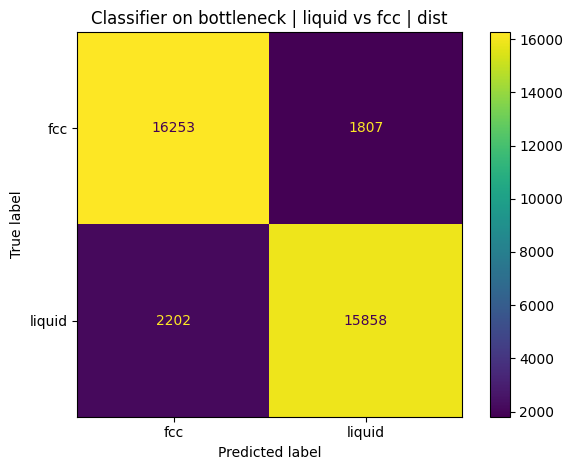

Classifier on bottleneck | liquid vs fcc | vec_dist
              precision    recall  f1-score   support

         fcc       0.50      0.50      0.50     18060
      liquid       0.50      0.50      0.50     18060

    accuracy                           0.50     36120
   macro avg       0.50      0.50      0.50     36120
weighted avg       0.50      0.50      0.50     36120



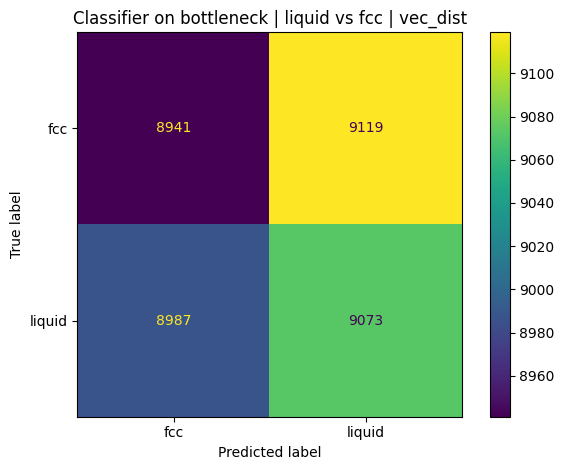

Classifier on bottleneck | liquid vs fcc | ql
              precision    recall  f1-score   support

         fcc       1.00      1.00      1.00     18060
      liquid       1.00      1.00      1.00     18060

    accuracy                           1.00     36120
   macro avg       1.00      1.00      1.00     36120
weighted avg       1.00      1.00      1.00     36120



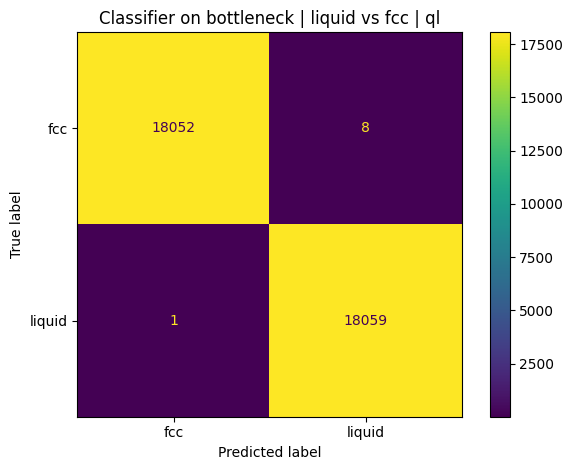

In [23]:
for kind in ["dist", "vec_dist", "ql"]:
    run_classifier_on_latent(
        ae_results_2[kind]["Z"],
        ae_results_2[kind]["y"],
        title=f"Classifier on bottleneck | liquid vs fcc | {kind}"
    )


## 7) Autoencoder for `liquid` vs `fcc` vs `hcp`


In [24]:
selected_phases_3 = ["liquid", "fcc", "hcp"]
ae_results_3 = {}

for kind in ["dist", "vec_dist", "ql"]:
    X_ae, y_ae, q4_ae, q6_ae, scaler = make_ae_data(kind, selected_phases_3)
    model, hist, Z = train_shallow_ae(
        X_ae, y_ae,
        latent_dim=LATENT_DIM,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        lr=LR
    )

    ae_results_3[kind] = {
        "X": X_ae,
        "y": y_ae,
        "q4": q4_ae,
        "q6": q6_ae,
        "scaler": scaler,
        "model": model,
        "history": hist,
        "Z": Z
    }


Balancing classes to 90300 samples each
Balancing classes to 90300 samples each
Balancing classes to 90300 samples each


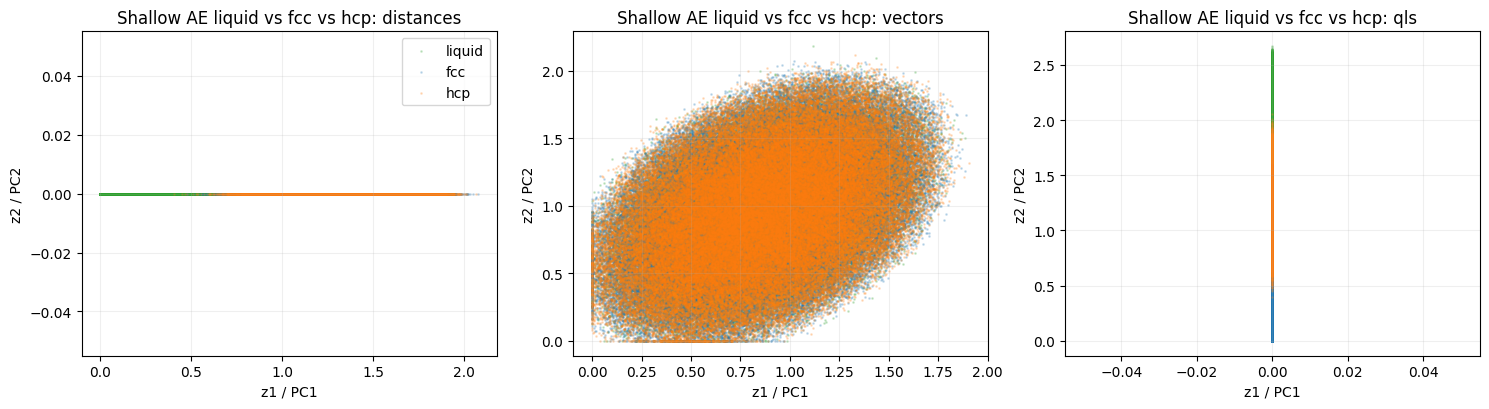

In [33]:
plot_ae_row(ae_results_3, selected_phases_3, "Shallow AE liquid vs fcc vs hcp")

In [40]:
def plot_ae_row_with_randomized(results_dict, selected_phases, title_prefix, noise_scale=0.02):

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
    kinds = ["dist", "vec_dist", "ql"]
    nice_titles = {"dist": "distances", "vec_dist": "vectors", "ql": "qls"}

    rng = np.random.default_rng(0)

    for ax, kind in zip(axes, kinds):

        Z = results_dict[kind]["Z"]
        y = results_dict[kind]["y"]

        if Z.shape[1] > 2:
            Z = PCA(n_components=2).fit_transform(Z)

        x = Z[:, 0].copy()
        y_lat = Z[:, 1].copy()

        # manual randomization rules
        if kind == "dist":
            y_lat = rng.normal(0, noise_scale, size=len(y_lat))

        elif kind == "ql":
            x = rng.normal(0, noise_scale, size=len(x))

        # vec_dist stays unchanged

        for phase in selected_phases:
            lab = LABEL_MAP[phase]
            mask = (y == lab)

            ax.scatter(
                x[mask],
                y_lat[mask],
                s=SCATTER_S,
                alpha=SCATTER_ALPHA,
                color=LABEL_COLORS[lab],
                label=phase
            )

        ax.set_title(f"{title_prefix}: {nice_titles[kind]}")
        ax.set_xlabel("latent dim 1")
        ax.set_ylabel("latent dim 2")
        ax.grid(alpha=0.2)

    handles, labels = axes[0].get_legend_handles_labels()
    axes[0].legend(handles, labels)

    plt.tight_layout()
    plt.show()

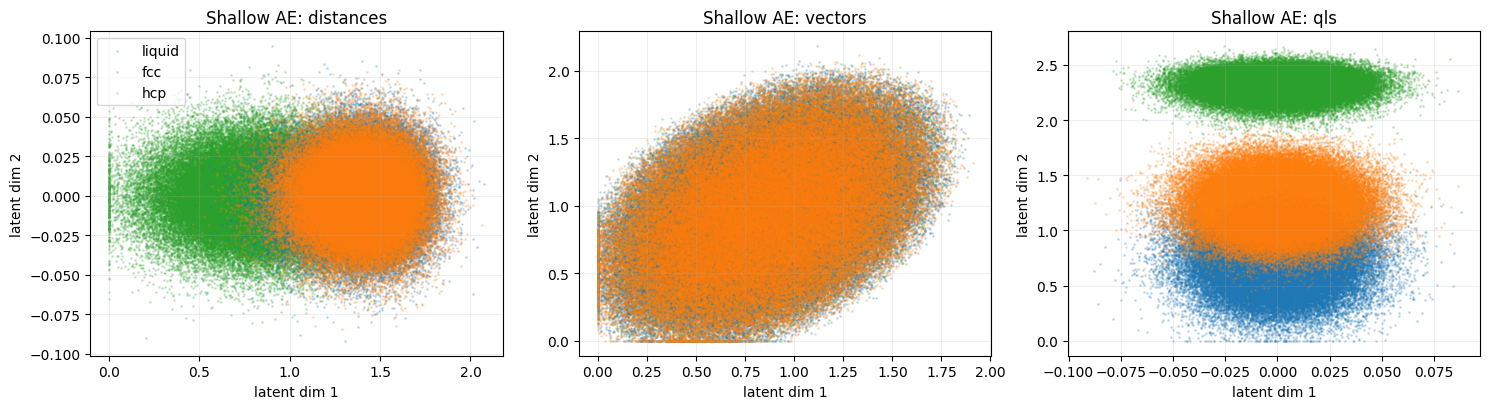

In [41]:
plot_ae_row_with_randomized(ae_results_3, selected_phases_3, "Shallow AE", noise_scale=0.02)


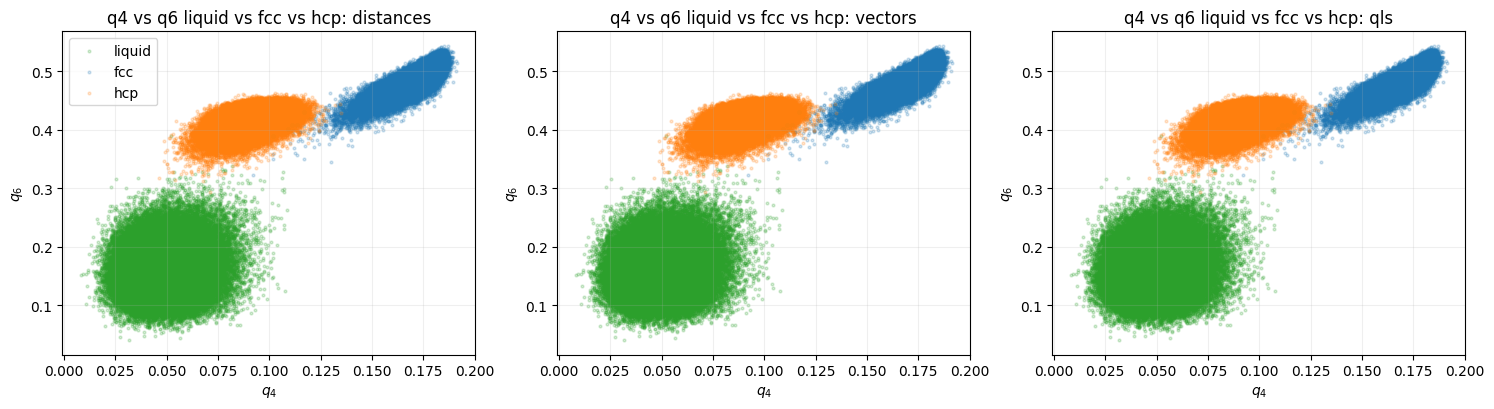

In [26]:
plot_q4q6_row(ae_results_3, selected_phases_3, "q4 vs q6 liquid vs fcc vs hcp")

Classifier on bottleneck | liquid vs fcc vs hcp | dist
              precision    recall  f1-score   support

         fcc       0.44      0.37      0.40     18060
         hcp       0.49      0.53      0.51     18060
      liquid       0.81      0.88      0.84     18060

    accuracy                           0.59     54180
   macro avg       0.58      0.59      0.59     54180
weighted avg       0.58      0.59      0.59     54180



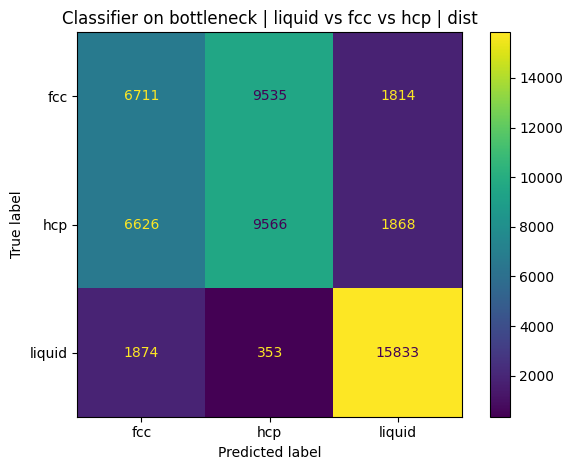

Classifier on bottleneck | liquid vs fcc vs hcp | vec_dist
              precision    recall  f1-score   support

         fcc       0.33      0.37      0.35     18060
         hcp       0.34      0.37      0.35     18060
      liquid       0.33      0.26      0.29     18060

    accuracy                           0.33     54180
   macro avg       0.33      0.33      0.33     54180
weighted avg       0.33      0.33      0.33     54180



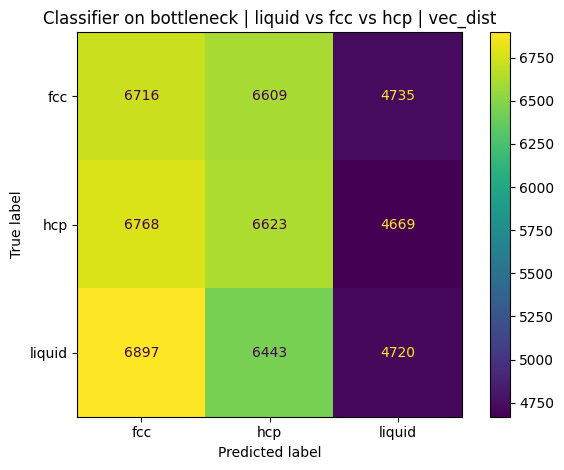

Classifier on bottleneck | liquid vs fcc vs hcp | ql
              precision    recall  f1-score   support

         fcc       0.85      0.83      0.84     18060
         hcp       0.83      0.86      0.84     18060
      liquid       1.00      1.00      1.00     18060

    accuracy                           0.90     54180
   macro avg       0.90      0.90      0.90     54180
weighted avg       0.90      0.90      0.90     54180



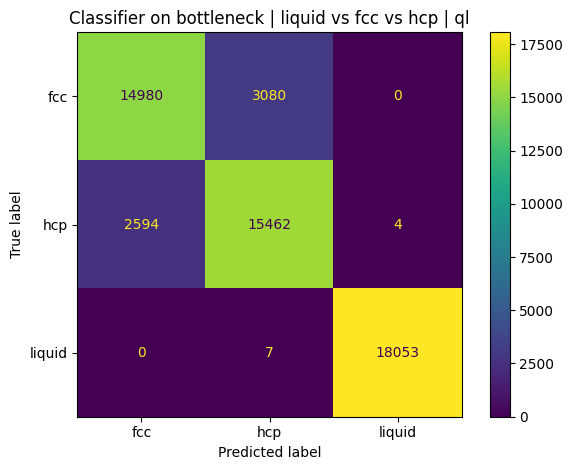

In [27]:
for kind in ["dist", "vec_dist", "ql"]:
    run_classifier_on_latent(
        ae_results_3[kind]["Z"],
        ae_results_3[kind]["y"],
        title=f"Classifier on bottleneck | liquid vs fcc vs hcp | {kind}"
    )


## 8) Training curves


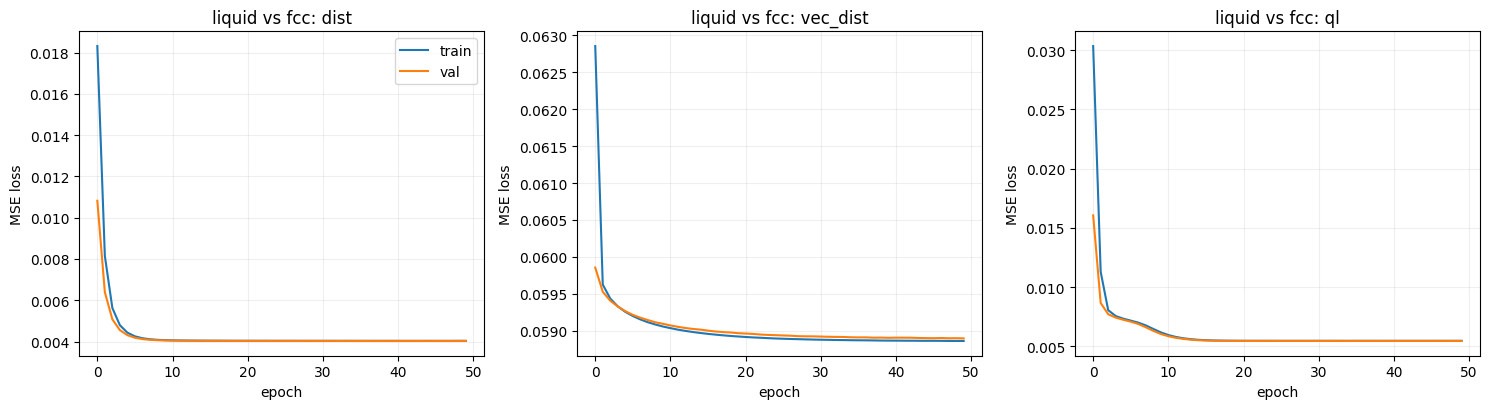

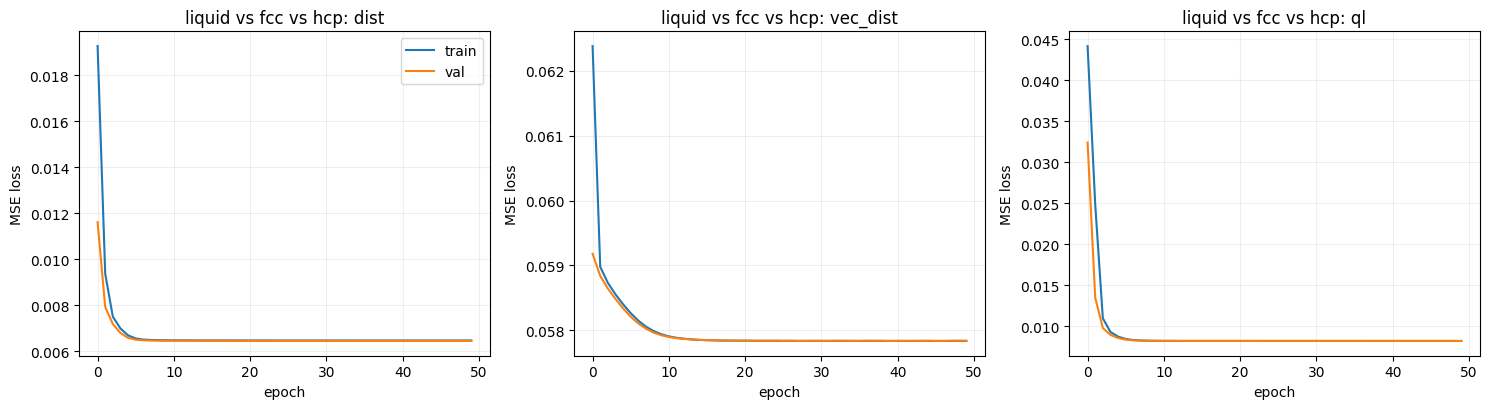

In [43]:
def plot_training_curves(results_dict, title_prefix):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
    kinds = ["dist", "vec_dist", "ql"]

    for ax, kind in zip(axes, kinds):
        hist = results_dict[kind]["history"]
        ax.plot(hist["loss"], label="train")
        ax.plot(hist["val_loss"], label="val")
        ax.set_title(f"{title_prefix}: {kind}")
        ax.set_xlabel("epoch")
        ax.set_ylabel("MSE loss")
        ax.grid(alpha=0.2)

    axes[0].legend()
    plt.tight_layout()
    plt.show()

# Examples:
plot_training_curves(ae_results_2, "liquid vs fcc")
plot_training_curves(ae_results_3, "liquid vs fcc vs hcp")
